# Customer Churn - Exploratory Data Analysis
### Dataset: Telco Customer Churn
### Name: Lahari Prasanna Desetty

##Dataset loading

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [3]:
import polars as pl

In [4]:
df=pl.read_csv("Telco-Customer-Churn.csv")
df.head()

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
str,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,f64,f64,str
"""7590-VHVEG""","""Female""",0,"""Yes""","""No""",1,"""No""","""No phone service""","""DSL""","""No""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",29.85,29.85,"""No"""
"""5575-GNVDE""","""Male""",0,"""No""","""No""",34,"""Yes""","""No""","""DSL""","""Yes""","""No""","""Yes""","""No""","""No""","""No""","""One year""","""No""","""Mailed check""",56.95,1889.5,"""No"""
"""3668-QPYBK""","""Male""",0,"""No""","""No""",2,"""Yes""","""No""","""DSL""","""Yes""","""Yes""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Mailed check""",53.85,108.15,"""Yes"""
"""7795-CFOCW""","""Male""",0,"""No""","""No""",45,"""No""","""No phone service""","""DSL""","""Yes""","""No""","""Yes""","""Yes""","""No""","""No""","""One year""","""No""","""Bank transfer (automatic)""",42.3,1840.75,"""No"""
"""9237-HQITU""","""Female""",0,"""No""","""No""",2,"""Yes""","""No""","""Fiber optic""","""No""","""No""","""No""","""No""","""No""","""No""","""Month-to-month""","""Yes""","""Electronic check""",70.7,151.65,"""Yes"""


In [5]:
print("Shape:", df.shape)

Shape: (7043, 21)


In [6]:
print("Column Names:\n", df.columns)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
print("Data Types:\n", df.dtypes)

Data Types:
 [String, String, Int64, String, String, Int64, String, String, String, String, String, String, String, String, String, String, String, String, Float64, Float64, String]


In [8]:
print(df.describe())

shape: (9, 22)
┌────────────┬────────────┬────────┬────────────┬───┬────────────┬────────────┬────────────┬───────┐
│ statistic  ┆ customerID ┆ gender ┆ SeniorCiti ┆ … ┆ PaymentMet ┆ MonthlyCha ┆ TotalCharg ┆ Churn │
│ ---        ┆ ---        ┆ ---    ┆ zen        ┆   ┆ hod        ┆ rges       ┆ es         ┆ ---   │
│ str        ┆ str        ┆ str    ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---        ┆ str   │
│            ┆            ┆        ┆ f64        ┆   ┆ str        ┆ f64        ┆ f64        ┆       │
╞════════════╪════════════╪════════╪════════════╪═══╪════════════╪════════════╪════════════╪═══════╡
│ count      ┆ 7043       ┆ 7043   ┆ 7043.0     ┆ … ┆ 7043       ┆ 7043.0     ┆ 7032.0     ┆ 7043  │
│ null_count ┆ 0          ┆ 0      ┆ 0.0        ┆ … ┆ 0          ┆ 0.0        ┆ 11.0       ┆ 0     │
│ mean       ┆ null       ┆ null   ┆ 0.162147   ┆ … ┆ null       ┆ 64.761692  ┆ 2283.30044 ┆ null  │
│            ┆            ┆        ┆            ┆   ┆            ┆          

## Dataset Overview

- Total Rows: 7043
- Total Columns: 21
- Target Column: Churn (Yes/No)
- Numerical Columns: SeniorCitizen, tenure, MonthlyCharges, TotalCharges
- Categorical Columns: gender, Partner, Dependents, Contract, PaymentMethod etc.

### Key Observation:
- TotalCharges has 11 missing values that need to be handled
- All other columns have no missing values

## Data Cleaning
Handling missing values, duplicates, unnecessary columns and inconsistent values

In [9]:
print("Missing Values in Each Column:")
print(df.null_count())

Missing Values in Each Column:
shape: (1, 21)
┌────────────┬────────┬─────────────┬─────────┬───┬─────────────┬─────────────┬────────────┬───────┐
│ customerID ┆ gender ┆ SeniorCitiz ┆ Partner ┆ … ┆ PaymentMeth ┆ MonthlyChar ┆ TotalCharg ┆ Churn │
│ ---        ┆ ---    ┆ en          ┆ ---     ┆   ┆ od          ┆ ges         ┆ es         ┆ ---   │
│ u32        ┆ u32    ┆ ---         ┆ u32     ┆   ┆ ---         ┆ ---         ┆ ---        ┆ u32   │
│            ┆        ┆ u32         ┆         ┆   ┆ u32         ┆ u32         ┆ u32        ┆       │
╞════════════╪════════╪═════════════╪═════════╪═══╪═════════════╪═════════════╪════════════╪═══════╡
│ 0          ┆ 0      ┆ 0           ┆ 0       ┆ … ┆ 0           ┆ 0           ┆ 11         ┆ 0     │
└────────────┴────────┴─────────────┴─────────┴───┴─────────────┴─────────────┴────────────┴───────┘


In [10]:
df = df.drop_nulls()
print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (7032, 21)


In [11]:
print("Duplicate Rows:", df.is_duplicated().sum())

Duplicate Rows: 0


In [12]:
df = df.drop('customerID')
print("Shape after dropping customerID:", df.shape)

Shape after dropping customerID: (7032, 20)


In [13]:
cat_cols = [col for col in df.columns if df[col].dtype == pl.Utf8]

for col in cat_cols:
    print(f"{col} → {df[col].unique().to_list()}")
    print()

gender → ['Female', 'Male']

Partner → ['No', 'Yes']

Dependents → ['Yes', 'No']

PhoneService → ['Yes', 'No']

MultipleLines → ['No', 'No phone service', 'Yes']

InternetService → ['DSL', 'No', 'Fiber optic']

OnlineSecurity → ['No', 'Yes', 'No internet service']

OnlineBackup → ['No', 'No internet service', 'Yes']

DeviceProtection → ['No', 'No internet service', 'Yes']

TechSupport → ['No internet service', 'Yes', 'No']

StreamingTV → ['No', 'Yes', 'No internet service']

StreamingMovies → ['Yes', 'No internet service', 'No']

Contract → ['Month-to-month', 'One year', 'Two year']

PaperlessBilling → ['No', 'Yes']

PaymentMethod → ['Credit card (automatic)', 'Bank transfer (automatic)', 'Mailed check', 'Electronic check']

Churn → ['Yes', 'No']



## Data Cleaning Summary

#### 1. **Missing Values** → TotalCharges had 11 missing values → Dropped those rows
#### 2. **Duplicate Rows** → 0 duplicates found → No action needed
#### 3. **Unnecessary Columns** → Dropped customerID as it has no analytical value
#### 4. **Inconsistent Values** → All categorical columns are clean and consistent
#### 5. **Final Shape after Cleaning** → (7032, 20)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Exploratory Data Analysis



## Univariate Analysis
Analyzing one column at a time to understand distributions and patterns.

###Bar plot

/tmp/ipykernel_3514/579817383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_counts['Churn'].to_list(), y=churn_counts['count'].to_list(), palette='Set2')


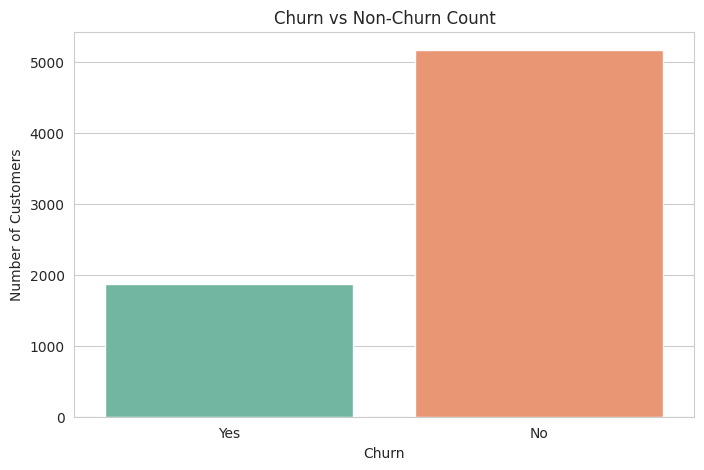

In [15]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_counts['Churn'].to_list(), y=churn_counts['count'].to_list(), palette='Set2')
plt.title('Churn vs Non-Churn Count')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

### Observation

- Out of 7032 customers, majority of customers did not churn
- Non-churned customers are significantly higher than churned customers
- This tells us the dataset is **imbalanced** — meaning churn cases are
lesser than non-churn cases
- This is typical in real business scenarios where most customers stay

### Pie chart

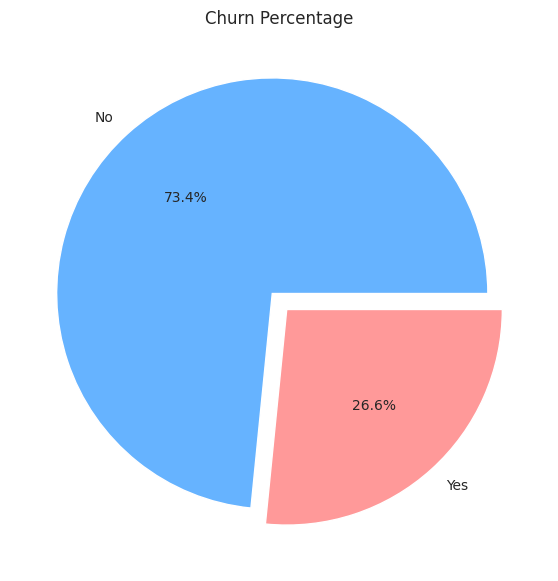

In [16]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(churn_counts['count'].to_list(),
        labels=churn_counts['Churn'].to_list(),
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'],
        explode=(0.05, 0.05))
plt.title('Churn Percentage')
plt.show()

### Observation - Churn Percentage Pie Chart

- 26.6% of customers churned — meaning roughly 1 in 4 customers left
- 73.4% of customers stayed with the company


###Histogram

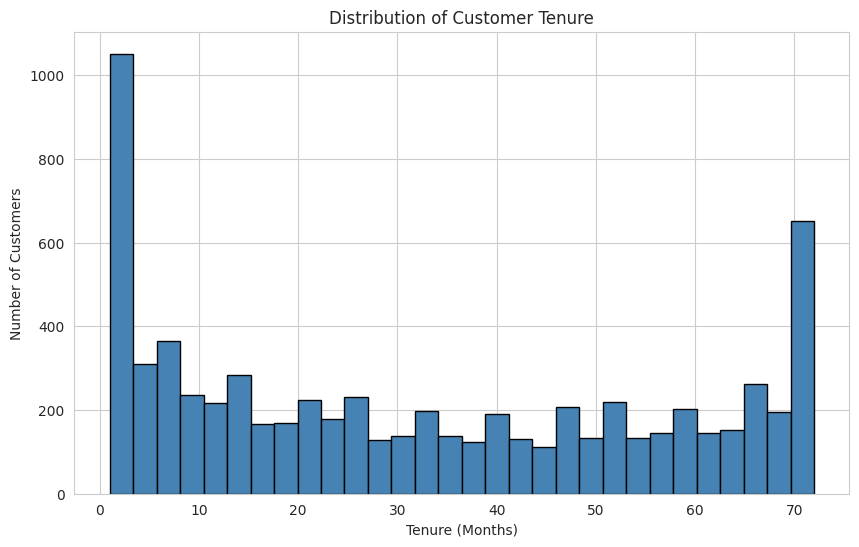

In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['tenure'].to_list(), bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.show()

### Observation - Tenure Distribution Histogram

- Distribution is U-shaped
- Large spike at 0-2 months (1000+ customers) — many new customers
- Another spike at 70+ months (650+ customers) — loyal long term customers
- Middle range (10-60 months) is relatively stable
- New customers are more likely to churn than long term customers

## Bivariate Analysis
Comparing important features directly with Churn to find patterns

###Box plot

/tmp/ipykernel_3514/2419743039.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['Churn'].to_list(),


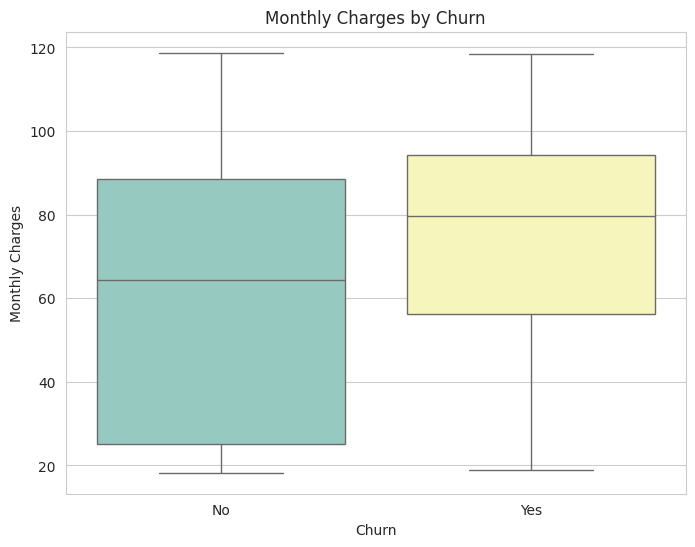

In [18]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Churn'].to_list(),
            y=df['MonthlyCharges'].to_list(),
            palette='Set3')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

### Observation - Monthly Charges by Churn (Boxplot)

- Churned customers have higher monthly charges compared to non-churned customers
- This suggests customers with higher monthly bills are more likely to churn
- No outliers detected in either group


###Count plot 1

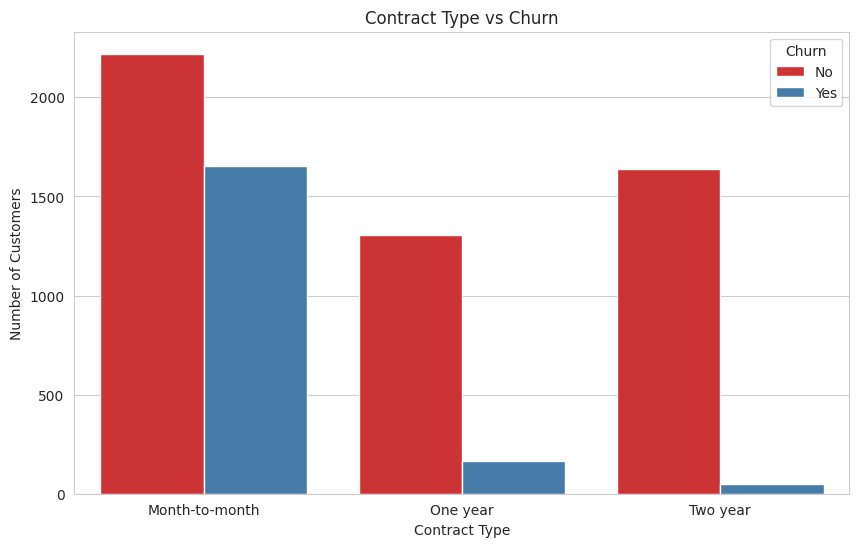

In [19]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['Contract'].to_list(),
              hue=df['Churn'].to_list(),
              palette='Set1')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Observation - Contract Type vs Churn (Bar Chart)

- Month-to-month contract customers churn the most (~1650 customers)
- One year contract customers churn very little (~175 customers)
- Two year contract customers almost never churn (~60 customers)
- This is a very strong pattern — longer the contract, lower the churn
- Company should focus on moving customers from month-to-month
to longer term contracts to reduce churn

###Count plot 2

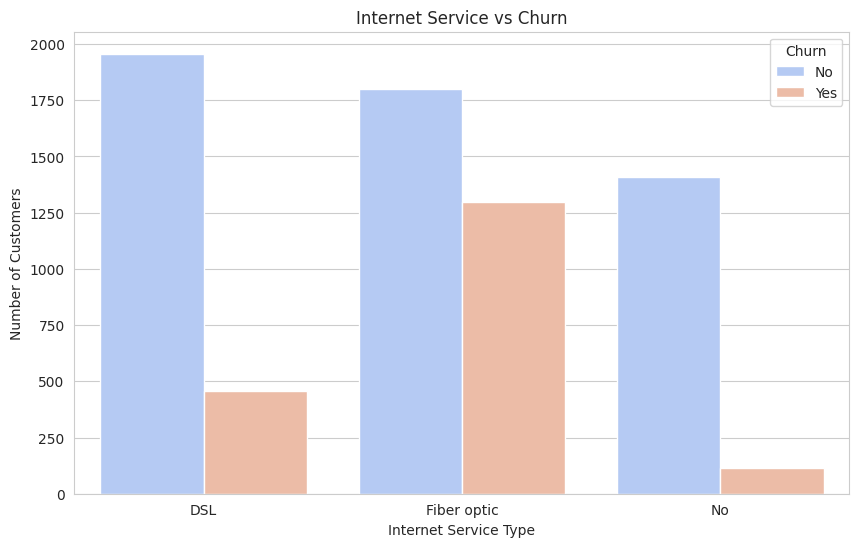

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df['InternetService'].to_list(),
              hue=df['Churn'].to_list(),
              palette='coolwarm')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

### Observation - Internet Service vs Churn (Bar Chart)

- Fiber optic customers churn the most (~1300 customers)
- DSL customers churn moderately (~450 customers)
- Customers with no internet service barely churn (~125 customers)
- Fiber optic has almost equal churn and non-churn bars which is alarming
- This suggests fiber optic customers may be dissatisfied possibly
due to high costs or service quality issues
- Company should investigate why fiber optic customers are leaving at such high rates

### Correlation matrix

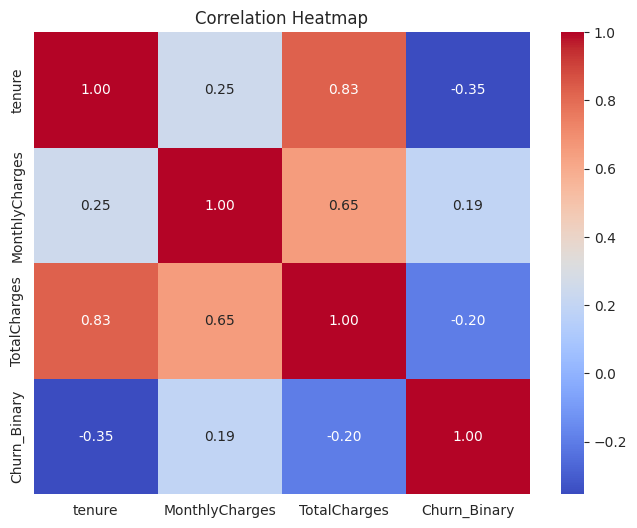

In [21]:
df_corr = df.with_columns(
    pl.col('Churn').map_elements(lambda x: 1 if x == 'Yes' else 0).alias('Churn_Binary')
)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary']

corr_matrix = df_corr.select(num_cols).to_pandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Observation - Correlation Heatmap

- Tenure has the strongest negative correlation with churn (-0.35)
  meaning longer staying customers are less likely to churn
- MonthlyCharges has a positive correlation with churn (0.19)
  meaning higher monthly bills lead to more churn
- TotalCharges has a negative correlation (-0.20) because long term
  customers naturally accumulate higher total charges
- Tenure and TotalCharges are strongly correlated (0.83) which makes
  sense as longer staying customers pay more overall
- Key insight: Tenure is the most important numerical factor for churn

### Scatter plot

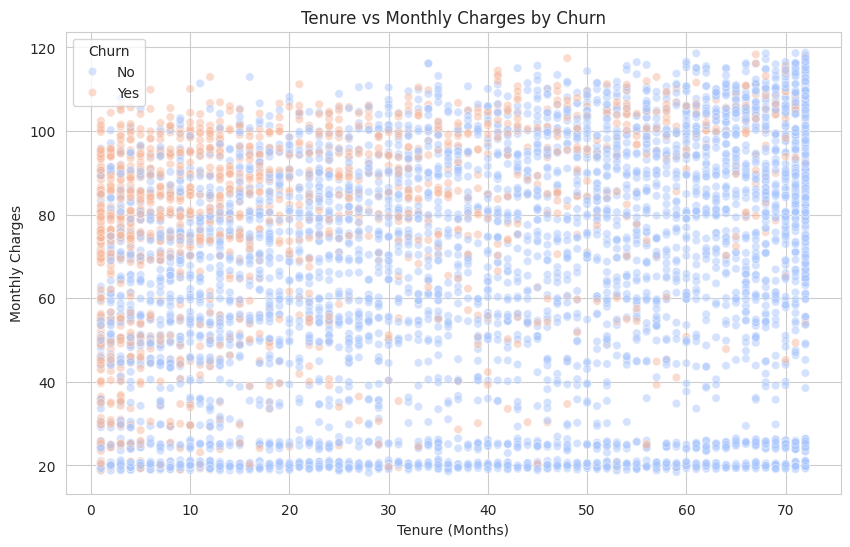

In [22]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['tenure'].to_list(),
                y=df['MonthlyCharges'].to_list(),
                hue=df['Churn'].to_list(),
                palette='coolwarm',
                alpha=0.5)
plt.title('Tenure vs Monthly Charges by Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Monthly Charges')
plt.legend(title='Churn')
plt.show()

### Observation - Tenure vs Monthly Charges Scatter Plot

- Churned customers (red) are heavily concentrated on the left side
  meaning they have low tenure (new customers)
- Churned customers also tend to be at the higher end of monthly charges
- Non-churned customers (blue) dominate the right side
  meaning long term customers rarely churn
- This confirms our earlier findings — new customers with high monthly
  charges are the most likely to churn
- The combination of low tenure and high monthly charges is a strong
  signal of potential churn

### Numerical Analysis
Mean, Median, Minimum, Maximum and Standard Deviation of numerical columns

In [23]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    print(f"Column: {col}")
    print(f"  Mean    : {df[col].mean():.2f}")
    print(f"  Median  : {df[col].median():.2f}")
    print(f"  Min     : {df[col].min():.2f}")
    print(f"  Max     : {df[col].max():.2f}")
    print(f"  Std Dev : {df[col].std():.2f}")
    print()

Column: tenure
  Mean    : 32.42
  Median  : 29.00
  Min     : 1.00
  Max     : 72.00
  Std Dev : 24.55

Column: MonthlyCharges
  Mean    : 64.80
  Median  : 70.35
  Min     : 18.25
  Max     : 118.75
  Std Dev : 30.09

Column: TotalCharges
  Mean    : 2283.30
  Median  : 1397.47
  Min     : 18.80
  Max     : 8684.80
  Std Dev : 2266.77



### Observation - Numerical Analysis

**Tenure:**
- Average customer stays for 32 months
- Median is 29 months meaning half the customers leave before 29 months
- Ranges from 1 to 72 months
- High std dev (24.55) means tenure varies widely across customers

**Monthly Charges:**
- Average monthly charge is 64.80
- Median is 70.35 which is higher than mean suggesting some low charge customers
- Ranges from 18.25 to 118.75
- High std dev (30.09) means customers are on very different price plans

**Total Charges:**
- Average total charge is 2283.30
- Median is 1397.47 which is much lower than mean
- This large gap between mean and median suggests some customers
  have been around very long and paid very high total amounts
- Ranges from 18.80 to 8684.80

### Outlier Analysis
Checking for outliers in numerical columns using the IQR method

In [25]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df.filter((pl.col(col) < lower_bound) | (pl.col(col) > upper_bound))
    print(f"Column: {col}")
    print(f"  Q1          : {Q1:.2f}")
    print(f"  Q3          : {Q3:.2f}")
    print(f"  IQR         : {IQR:.2f}")
    print(f"  Lower Bound : {lower_bound:.2f}")
    print(f"  Upper Bound : {upper_bound:.2f}")
    print(f"  Outliers    : {outliers.shape[0]}")
    print()

Column: tenure
  Q1          : 9.00
  Q3          : 55.00
  IQR         : 46.00
  Lower Bound : -60.00
  Upper Bound : 124.00
  Outliers    : 0

Column: MonthlyCharges
  Q1          : 35.60
  Q3          : 89.85
  IQR         : 54.25
  Lower Bound : -45.77
  Upper Bound : 171.22
  Outliers    : 0

Column: TotalCharges
  Q1          : 401.50
  Q3          : 3794.50
  IQR         : 3393.00
  Lower Bound : -4688.00
  Upper Bound : 8884.00
  Outliers    : 0



### Observation - Outlier Analysis (IQR Method)

- 0 outliers found in all three columns (tenure, MonthlyCharges, TotalCharges)
- All values are within the normal IQR bounds
- Dataset is clean and no outlier treatment is needed

## Final Insights

### Key Churn Patterns

1. 26.6% of customers churned — roughly 1 in 4 customers left
2. Month-to-month contract customers churn the most
3. Fiber optic internet service customers have very high churn rate
4. New customers with low tenure (0-2 months) are most at risk
5. Customers with higher monthly charges tend to churn more
6. Long term customers (70+ months) are very loyal and rarely churn
7. Tenure is the strongest numerical predictor of churn (-0.35)
8. Contract type is the strongest categorical predictor of churn

## Business Recommendations

1. **Promote Long Term Contracts**
   - Offer discounts and benefits to customers on month-to-month
     contracts to switch to one or two year contracts

2. **Early Retention Programs**
   - Target new customers in their first 6 months with special
     offers and personalized engagement as they are most at risk

3. **Investigate Fiber Optic Service**
   - Fiber optic customers churn at very high rates — investigate
     whether this is due to pricing or service quality issues

4. **Review High Charge Customers**
   - Offer flexible pricing plans or bundled discounts to customers
     with high monthly charges to prevent them from leaving

5. **Loyalty Rewards Program**
   - Introduce rewards for customers who stay beyond 12 months
     to encourage long term retention